# Phase 1: Alpha Evaluation with Splits, Costs, Turnover, and Risk Metrics

## Objective

This notebook upgrades the Phase 0 alpha evaluator by adding:

1. Train / validation / test splits
2. Transaction costs
3. Turnover
4. Max drawdown
5. Rolling Rank IC
6. Alpha correlation matrix
7. A final keep / reject / modify decision for each alpha

In [2]:
# Import necessary libraries and dowwnload required info

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import yfinance as yf


tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "JPM", "UNH", "XOM", "PG",
    "HD", "V", "MA", "BAC", "KO",
    "PEP", "AVGO", "COST", "WMT", "DIS"
]

# auto_adjust=True: prices are adjusted for corporate actions (splits/dividends). 
# This helps avoid “artificial” jumps in historical prices.

# group_by="ticker": the returned dataframe is structured so raw[ticker] gives the 
# OHLCV columns for that ticker.

raw = yf.download(
    tickers,
    start="2018-01-01",
    end="2025-12-31",
    auto_adjust=True,
    group_by="ticker"
)

[*********************100%***********************]  20 of 20 completed


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# print(DATA_DIR)
DATA_DIR.mkdir(parents=True, exist_ok=True)

## Convert raw yfinance output into a panel dataframe

`yfinance.download(..., group_by="ticker")` returns a dataframe where each ticker has its own OHLCV sub-table.
For alpha research it’s much easier to work with a single “panel” (long-form) dataframe.

In the loop below, for each `ticker` we:
1. Take the OHLCV rows for that ticker (`raw[ticker]`)
2. Normalize column names (lowercase, spaces -> underscores)
3. Add:
   - `ticker`: the stock identifier
   - `date`: the row timestamp from the index
4. Concatenate all tickers into one dataframe (`df`)

Finally we sort by `["ticker", "date"]` so that time-series operations like `shift`, `pct_change`, and `rolling`
are applied in the correct chronological order per ticker.

In [4]:
frames = []

for ticker in tickers:
    temp = raw[ticker].copy()
    temp.columns = [c.lower().replace(" ", "_") for c in temp.columns]
    temp["ticker"] = ticker
    temp["date"] = temp.index
    frames.append(temp)

df = pd.concat(frames)
df = df.reset_index(drop=True)
df = df.sort_values(["ticker", "date"])
df.to_csv(DATA_DIR / "prices_panel.csv", index=False)


## Create the prediction target and five simple alpha features

We evaluate signals by measuring how well an alpha at time `t` predicts the **forward return** from `t` to `t+1`.

### Target: next-day close-to-close return
For each ticker, we compute:

- `future_return_1d(t) = close(t+1) / close(t) - 1`

So a model that works would produce alpha values that are positively correlated with `future_return_1d`.

### Alpha definitions
For each ticker, we also compute these features at time `t`:

1. **`momentum_5d` (5-day momentum)**
   - `momentum_5d(t) = close(t) / close(t-5) - 1`
   - What it means: positive values indicate the price has risen over the past ~5 trading days.
   - Intuition: if momentum exists, strong recent winners tend to continue (and vice versa).

2. **`mean_reversion_1d` (1-day mean reversion)**
   - `mean_reversion_1d(t) = - (close(t) / close(t-1) - 1)`
   - What it means: it is the negative of yesterday’s return.
   - Intuition: after a short-term drop, the alpha becomes positive (suggesting a bounce next day).

3. **`volume_spike` (volume anomaly vs 20-day average)**
   - `volume_spike(t) = volume(t) / MA(volume, 20)(t) - 1`
   - What it means: positive values indicate volume is above its recent average.
   - Intuition: unusual activity may precede price moves, but direction can vary by regime.

4. **`volatility_breakout` (intraday range / close)**
   - `volatility_breakout(t) = (high(t) - low(t)) / close(t)`
   - What it means: a simple measure of today’s intraday movement relative to price.
   - Intuition: large ranges can be associated with breakouts or regime shifts.

5. **`overnight_gap` (open relative to prior close)**
   - `overnight_gap(t) = open(t) / close(t-1) - 1`
   - What it means: how much price “gapped” between the prior close and today’s open.
   - Intuition: gaps can predict next-day behavior, but the relationship may depend on news impact.

> Note: all alphas are computed per ticker using rolling windows and percentage changes.
> The goal is not to “trade” yet, but to test whether each feature is correlated with forward returns.

In [5]:
g = df.groupby("ticker", group_keys=False)

df["future_return_1d"] = g["close"].shift(-1) / df["close"] - 1

df["momentum_5d"] = g["close"].pct_change(5)
df["mean_reversion_1d"] = -g["close"].pct_change(1)
df["volume_spike"] = df["volume"] / g["volume"].transform(lambda x: x.rolling(20).mean()) - 1
df["volatility_breakout"] = (df["high"] - df["low"]) / df["close"]
df["overnight_gap"] = df["open"] / g["close"].shift(1) - 1
df.to_csv(DATA_DIR / "prices_with_alpha.csv", index=False)


## Train / validation / test split

To avoid judging alphas only on the full sample, each row is tagged by calendar period:

| Split | Dates |
|-------|--------|
| **train** | 2018-01-01 through 2021-12-31 |
| **validation** | 2022-01-01 through 2023-12-31 |
| **test** | 2024-01-01 onward |

IC and backtest summaries can then answer: did the signal work in-sample, hold up in validation, and survive out-of-sample on the test window?

In [6]:
def assign_split(date):
    date = pd.Timestamp(date)
    if date < pd.Timestamp("2022-01-01"):
        return "train"
    elif date < pd.Timestamp("2024-01-01"):
        return "validation"
    else:
        return "test"


df["date"] = pd.to_datetime(df["date"])
df["split"] = df["date"].apply(assign_split)

df["split"].value_counts().sort_index()

df.to_csv(DATA_DIR / "prices_with_alpha_with_splits.csv", index=False)


## Compute daily Information Coefficient (IC)

The Information Coefficient (IC) measures how strongly an alpha correlates with realized future returns **across tickers on the same date**.

For each `date`:
1. Collect the alpha values (`alpha_col`) for all tickers on that date
2. Collect the realized forward returns (`future_return_1d`) for those same tickers
3. Drop missing values and require at least a minimum number of tickers
4. Compute:
   - **Pearson IC (`ic`)**: linear correlation
   - **Spearman Rank IC (`rank_ic`)**: correlation between ranks (monotonic relationship)

If an alpha is useful, then tickers with higher alpha scores on date `t` should tend to have higher realized `future_return_1d` on date `t`.

In [7]:
def daily_ic(data, alpha_col, target_col="future_return_1d"):
    results = []

    for date, group in data.groupby("date"):
        temp = group[[alpha_col, target_col]].dropna()

        if len(temp) < 5:
            continue

        pearson_ic = temp[alpha_col].corr(temp[target_col])
        rank_ic = spearmanr(temp[alpha_col], temp[target_col]).correlation

        results.append({
            "date": date,
            "alpha": alpha_col,
            "ic": pearson_ic,
            "rank_ic": rank_ic,
            "n": len(temp)
        })

    return pd.DataFrame(results)

## Evaluate and summarize all alphas with IC statistics

For each alpha feature we compute a daily series of:
- `ic` (Pearson IC)
- `rank_ic` (Spearman Rank IC)

Then we summarize performance across time:

- `mean_ic`: average daily Pearson IC
- `ic_std`: volatility (standard deviation) of daily IC
- `icir = mean_ic / ic_std`: a stability-adjusted IC score
- `mean_rank_ic`: average daily Rank IC
- `rank_ic_std`, `rank_icir`: same but for Rank IC

Finally, we sort by `mean_rank_ic` to find signals with the strongest average monotonic relationship
between alpha and next-day returns.

In [8]:
alpha_cols = [
    "momentum_5d",
    "mean_reversion_1d",
    "volume_spike",
    "volatility_breakout",
    "overnight_gap"
]

all_ic = pd.concat(
    [daily_ic(df, alpha) for alpha in alpha_cols],
    ignore_index=True
)
all_ic.to_csv(DATA_DIR / "alpha_with_ic_by_date.csv", index=False)


summary = (
    all_ic
    .groupby("alpha")
    .agg(
        mean_ic=("ic", "mean"),
        mean_rank_ic=("rank_ic", "mean"),
        ic_std=("ic", "std"),
        rank_ic_std=("rank_ic", "std"),
        observations=("ic", "count")
    )
)

summary["icir"] = summary["mean_ic"] / summary["ic_std"]
summary["rank_icir"] = summary["mean_rank_ic"] / summary["rank_ic_std"]
summary = summary.reset_index()

summary.sort_values("mean_rank_ic", ascending=False)
summary.to_csv(DATA_DIR / "performance_summary.csv", index=False)

## IC metrics by split

The overall `performance_summary.csv` mixes all years. Here we attach each daily IC row to its `split`, then aggregate mean IC, Rank IC, volatility, and ICIR **per alpha and per split** so you can compare train vs validation vs test without peeking at test when choosing signals.

In [9]:
date_to_split = df[["date", "split"]].drop_duplicates()
all_ic_by_split = all_ic.merge(date_to_split, on="date", how="left")

all_ic_by_split.to_csv(DATA_DIR / "alpha_with_ic_by_split.csv", index=False)


performance_by_split = (
    all_ic_by_split
    .groupby(["alpha", "split"])
    .agg(
        mean_ic=("ic", "mean"),
        mean_rank_ic=("rank_ic", "mean"),
        ic_std=("ic", "std"),
        rank_ic_std=("rank_ic", "std"),
        observations=("ic", "count"),
    )
    .reset_index()
)

performance_by_split["icir"] = (
    performance_by_split["mean_ic"] / performance_by_split["ic_std"]
)

performance_by_split["rank_icir"] = (
    performance_by_split["mean_rank_ic"] / performance_by_split["rank_ic_std"]
)

performance_by_split.sort_values(["alpha", "split"])

performance_by_split.to_csv(DATA_DIR / "performance_summary_by_split.csv", index=False)


## Pivot tables: Rank IC and Rank ICIR by split

One row per alpha, columns for train / validation / test — easier to scan than the long `performance_by_split` table.

Check: Is Rank IC positive in each split? Is Rank ICIR stable? Did the signal collapse on test?

split,train,validation,test
alpha,,,
mean_reversion_1d,0.026761,0.000133,-0.011077
momentum_5d,-0.011440,0.013924,-0.012891
overnight_gap,-0.003748,0.010936,0.027704
volatility_breakout,0.000836,-0.011724,0.018563
volume_spike,0.001331,-0.007875,-0.011105


split,train,validation,test
alpha,,,
mean_reversion_1d,0.081775,0.000406,-0.035383
momentum_5d,-0.034339,0.040271,-0.040790
overnight_gap,-0.011224,0.033998,0.084003
volatility_breakout,0.002647,-0.032164,0.059295
volume_spike,0.005119,-0.030149,-0.045388


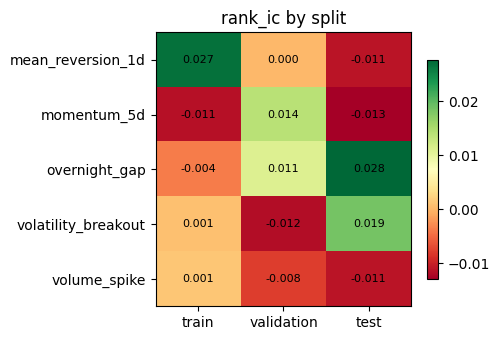

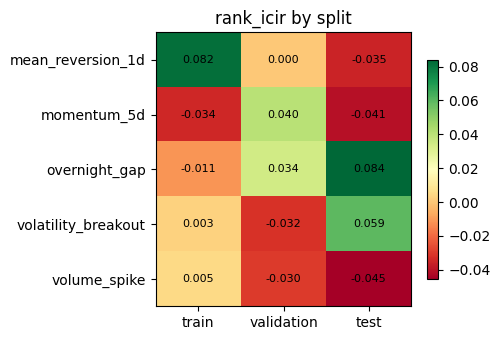

In [10]:
split_order = ["train", "validation", "test"]

rank_ic_pivot = performance_by_split.pivot(
    index="alpha",
    columns="split",
    values="mean_rank_ic",
)[split_order]

rank_icir_pivot = performance_by_split.pivot(
    index="alpha",
    columns="split",
    values="rank_icir",
)[split_order]

display(rank_ic_pivot)
display(rank_icir_pivot)

rank_ic_pivot.to_csv(DATA_DIR / "rank_ic_pivot.csv")
rank_icir_pivot.to_csv(DATA_DIR / "rank_icir_pivot.csv")

# Optional heatmaps for reports (tables above are the source of truth)
import matplotlib.pyplot as plt

for name, pivot in [("rank_ic", rank_ic_pivot), ("rank_icir", rank_icir_pivot)]:
    fig, ax = plt.subplots(figsize=(5, 3.5))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(f"{name} by split")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{name}_by_split.png", dpi=150, bbox_inches="tight")
    plt.show()

### Quick read: Rank IC by split + pattern label

Pivot `mean_rank_ic` to one row per alpha and apply simple rules (train / validation / test). Thresholds are rough heuristics for a 20-name universe—not hard cutoffs for live trading.

In [11]:
# Uses rank_ic_pivot from the cell above
# rank_ic_pivot = pd.read_csv(DATA_DIR / "rank_ic_pivot.csv", index_col=0)

wide = rank_ic_pivot
display(wide)


def pattern(row):
    t, v, te = row["train"], row["validation"], row["test"]
    if all(abs(x) < 0.01 for x in [t, v, te]):
        return "weak everywhere"
    if t > 0.02 and te < 0:
        return "strong train, weak test"
    if t < 0.01 and te > 0.02:
        return "weak train, strong test"
    if t > 0 and v > 0 and te > 0:
        return "stable (same sign)"
    return "mixed / unstable"


wide.assign(pattern=wide.apply(pattern, axis=1))

split,train,validation,test
alpha,,,
mean_reversion_1d,0.026761,0.000133,-0.011077
momentum_5d,-0.011440,0.013924,-0.012891
overnight_gap,-0.003748,0.010936,0.027704
volatility_breakout,0.000836,-0.011724,0.018563
volume_spike,0.001331,-0.007875,-0.011105


split,train,validation,test,pattern
alpha,,,,
mean_reversion_1d,0.026761,0.000133,-0.011077,"strong train, weak test"
momentum_5d,-0.011440,0.013924,-0.012891,mixed / unstable
overnight_gap,-0.003748,0.010936,0.027704,"weak train, strong test"
volatility_breakout,0.000836,-0.011724,0.018563,mixed / unstable
volume_spike,0.001331,-0.007875,-0.011105,mixed / unstable


## Simple cross-sectional long/short backtest (top/bottom quantiles)

IC tells us whether an alpha is *correlated* with next-day returns, but it does not directly answer:
“**If I trade this signal, do I make money?**”

Here we run a very simple daily long/short simulation:

For each trading date `t`:
1. Take all tickers with non-missing values for:
   - the alpha score `alpha_col(t)`
   - the realized next-day return `future_return_1d(t)`
2. Rank tickers by the alpha score and split into quantiles.
3. **Go long** the top `q` fraction by alpha (e.g., top 20%).
4. **Go short** the bottom `q` fraction by alpha (e.g., bottom 20%).
5. Compute the portfolio’s next-day return as:


### Key terms
- **Cross-sectional**: we compare stocks *to each other on the same day* (not one stock over time).
- **Quantile**: a threshold based on the alpha distribution each day (e.g., 0.2 means 20% tails).
- **Long-short return**: the difference between average returns of the long and short baskets.
- **Dollar-neutral intuition**: long and short legs are equally weighted (by simple averaging here), so market direction is partly hedged—but not perfectly.

> Important: This is a research-grade “toy” backtest: it ignores transaction costs, borrow fees, slippage,
> corporate actions edge cases, and realistic portfolio constraints. It’s still a great first sanity check.

In [12]:
def long_short_backtest(data, alpha_col, target_col="future_return_1d", quantile=0.2):
    rows = []

    for date, group in data.groupby("date"):
        temp = group[[alpha_col, target_col]].dropna()

        if len(temp) < 10:
            continue

        low_cutoff = temp[alpha_col].quantile(quantile)
        high_cutoff = temp[alpha_col].quantile(1 - quantile)

        # “Among the highest-alpha stocks today, what was their average return tomorrow?”
        long_return = temp.loc[temp[alpha_col] >= high_cutoff, target_col].mean()

        #   So: “Among the lowest-alpha stocks today, what was their average return tomorrow?”
        short_return = temp.loc[temp[alpha_col] <= low_cutoff, target_col].mean()

        rows.append({
            "date": date,
            "alpha": alpha_col,
            "long_return": long_return,
            "short_return": short_return,
            "long_short_return": long_return - short_return
        })

    return pd.DataFrame(rows)

## Daily long/short positions (for turnover and costs)

Phase 0 only returned portfolio returns. Phase 1 tracks **who** is long/short each day with weights:

- long leg sums to **+1**
- short leg sums to **-1**
- net exposure ≈ 0, gross exposure ≈ 2 (research convention; you may normalize gross to 1 later)

In [13]:
def get_daily_positions(data, alpha_col, quantile=0.2):
    position_rows = []

    for date, group in data.groupby("date"):
        temp = group[["ticker", alpha_col, "future_return_1d"]].dropna()

        if len(temp) < 10:
            continue

        low_cutoff = temp[alpha_col].quantile(quantile)
        high_cutoff = temp[alpha_col].quantile(1 - quantile)

        longs = temp[temp[alpha_col] >= high_cutoff]["ticker"].tolist()
        shorts = temp[temp[alpha_col] <= low_cutoff]["ticker"].tolist()

        n_long = len(longs)
        n_short = len(shorts)

        for ticker in longs:
            position_rows.append({
                "date": date,
                "ticker": ticker,
                "alpha": alpha_col,
                "weight": 1.0 / n_long if n_long > 0 else 0.0,
            })

        for ticker in shorts:
            position_rows.append({
                "date": date,
                "ticker": ticker,
                "alpha": alpha_col,
                "weight": -1.0 / n_short if n_short > 0 else 0.0,
            })

    return pd.DataFrame(position_rows)


all_positions = pd.concat(
    [get_daily_positions(df, alpha) for alpha in alpha_cols],
    ignore_index=True,
)
all_positions.to_csv(DATA_DIR / "daily_positions.csv", index=False)
all_positions.head(10)

,date,ticker,alpha,weight
0,2018-01-09,AMZN,momentum_5d,0.25
1,2018-01-09,MA,momentum_5d,0.25
2,2018-01-09,NVDA,momentum_5d,0.25
3,2018-01-09,V,momentum_5d,0.25
4,2018-01-09,COST,momentum_5d,-0.25
5,2018-01-09,DIS,momentum_5d,-0.25
6,2018-01-09,PEP,momentum_5d,-0.25
7,2018-01-09,PG,momentum_5d,-0.25
8,2018-01-10,AMZN,momentum_5d,0.25
9,2018-01-10,MA,momentum_5d,0.25


## Daily portfolio returns from positions

Multiply each position weight by `future_return_1d` and sum by `(alpha, date)` to get **gross_return**. This should match the Phase 0 `long_short_return` (long average − short average) when weights are equal within each leg.

In [14]:
def compute_position_returns(positions, data):
    returns_data = data[["date", "ticker", "future_return_1d", "split"]].copy()

    merged = positions.merge(
        returns_data,
        on=["date", "ticker"],
        how="left",
    )

    merged["weighted_return"] = merged["weight"] * merged["future_return_1d"]

    daily_returns = (
        merged
        .groupby(["alpha", "date"])
        .agg(
            gross_return=("weighted_return", "sum"),
            n_positions=("ticker", "count"),
        )
        .reset_index()
    )

    date_to_split = data[["date", "split"]].drop_duplicates()
    daily_returns = daily_returns.merge(date_to_split, on="date", how="left")

    return daily_returns


# all_positions built in the cell above
daily_returns = compute_position_returns(all_positions, df)

daily_returns.to_csv(DATA_DIR / "daily_returns.csv", index=False)

display(daily_returns.head(10))

gross_summary = daily_returns.groupby("alpha")["gross_return"].agg(["mean", "std", "count"])
display(gross_summary)

gross_by_split = daily_returns.groupby(["alpha", "split"])["gross_return"].mean().unstack("split")
display(gross_by_split)


,alpha,date,gross_return,n_positions,split
0,mean_reversion_1d,2018-01-03,0.007617,8,train
1,mean_reversion_1d,2018-01-04,-0.002927,8,train
2,mean_reversion_1d,2018-01-05,-0.002151,8,train
3,mean_reversion_1d,2018-01-08,0.004944,8,train
4,mean_reversion_1d,2018-01-09,-0.008176,8,train
5,mean_reversion_1d,2018-01-10,0.000968,8,train
6,mean_reversion_1d,2018-01-11,-0.025415,8,train
7,mean_reversion_1d,2018-01-12,0.000884,8,train
8,mean_reversion_1d,2018-01-16,0.003143,8,train
9,mean_reversion_1d,2018-01-17,-0.004268,8,train


,mean,std,count
alpha,,,
mean_reversion_1d,0.000313,0.015589,2008
momentum_5d,0.000022,0.016760,2004
overnight_gap,0.000493,0.016329,2008
volatility_breakout,0.000441,0.016308,2009
volume_spike,-0.000072,0.012748,1990


split,test,train,validation
alpha,,,
mean_reversion_1d,-0.000053,0.000831,-0.000364
momentum_5d,-0.000410,-0.000455,0.001406
overnight_gap,0.001123,0.000449,-0.000050
volatility_breakout,0.000697,0.000307,0.000456
volume_spike,0.000512,-0.000239,-0.000325


## Turnover: how much does the portfolio change each day?

**Turnover** measures the total absolute change in portfolio weights from one day to the next. For a long-short book:

| Turnover value | What it means |
|----------------|---------------|
| `0.0` | Portfolio did not change at all |
| `0.5` | About a quarter of the long leg (and short leg) was replaced |
| `1.0` | Large reshuffling — roughly half the gross book changed |
| `2.0` | Near-full replacement: almost every long and every short was swapped out |

**Why it matters:** every time a weight changes, you need to trade. Trading costs money (commissions, bid-ask spread, market impact). A signal with high turnover must have a *much* stronger gross return to survive those costs. A signal with low turnover is forgiving of costs.

### Concrete example

Suppose you hold four stocks long on 2024-01-02:

| Ticker | weight day t | weight day t+1 | change |
|--------|-------------|-----------------|--------|
| AAPL   | +0.25       | +0.25           | 0.00   |
| NVDA   | +0.25       | 0.00            | 0.25   |
| META   | 0.00        | +0.25           | 0.25   |
| AMZN   | +0.25       | +0.25           | 0.00   |

Sum of `|change|` on the long side = 0.50. Same logic on the short side. Total turnover ≈ 1.0 — you replaced one long and one short out of four each.

In [15]:
def compute_turnover(positions):
    turnover_rows = []

    for alpha, alpha_pos in positions.groupby("alpha"):
        alpha_pos = alpha_pos.copy()
        alpha_pos = alpha_pos.sort_values(["date", "ticker"])

        # Build a (date × ticker) weight matrix; missing = 0 (not held)
        position_matrix = alpha_pos.pivot_table(
            index="date",
            columns="ticker",
            values="weight",
            fill_value=0.0,
        )

        # Day-over-day change in each weight, then sum absolute changes across tickers
        # .diff() gives NaN on the first row, so we handle it separately
        daily_turnover = position_matrix.diff().abs().sum(axis=1)

        # First day: turnover = cost of opening the initial positions from scratch
        daily_turnover.iloc[0] = position_matrix.iloc[0].abs().sum()

        turnover_df = daily_turnover.reset_index()
        turnover_df.columns = ["date", "turnover"]
        turnover_df["alpha"] = alpha

        turnover_rows.append(turnover_df)

    return pd.concat(turnover_rows, ignore_index=True)


turnover_df = compute_turnover(all_positions)

# Attach turnover to daily_returns so each row has: alpha, date, gross_return, n_positions, split, turnover
daily_returns = daily_returns.merge(
    turnover_df,
    on=["alpha", "date"],
    how="left",
)

# Summary: average daily turnover per alpha
# Max turnover is 4 as one swap of one long produces two counts of 0.25 = 0.50 in turnover — one for the exit, one for the entry.
# and up to 8 swaps in total
turnover_summary = (
    daily_returns
    .groupby("alpha")["turnover"]
    .agg(mean_turnover="mean", max_turnover="max")
    .round(3)
)
display(turnover_summary)

# By split: did turnover change across regimes?
display(
    daily_returns
    .groupby(["alpha", "split"])["turnover"]
    .mean()
    .unstack("split")
    .round(3)
)

,mean_turnover,max_turnover
alpha,,
mean_reversion_1d,3.116,4.0
momentum_5d,1.454,4.0
overnight_gap,3.001,4.0
volatility_breakout,2.341,4.0
volume_spike,2.192,4.0


split,test,train,validation
alpha,,,
mean_reversion_1d,3.087,3.143,3.089
momentum_5d,1.423,1.483,1.429
overnight_gap,2.952,3.031,2.992
volatility_breakout,2.337,2.418,2.190
volume_spike,2.185,2.198,2.187


## Transaction costs

### What "5 basis points per unit of turnover" means

A **basis point (bps)** is 1/100th of 1%, i.e. `0.0001`.

`COST_PER_TURNOVER = 0.0005` means every unit of turnover costs **0.05%** of portfolio value:

- If you sell $100 of AAPL and buy $100 of NVDA, that is $200 traded, costing $0.10 (0.05% × $200).

This 5 bps models the **one-way** cost of crossing the bid-ask spread on liquid large-cap stocks. It is conservative (real costs can be higher after market impact, borrow fees on the short side, and commissions). It is intentionally simple for Phase 1.

### The formula

```
transaction_cost(day t) = turnover(day t) × COST_PER_TURNOVER
net_return(day t)       = gross_return(day t) − transaction_cost(day t)
```

### Annualised Sharpe comparison

Sharpe ratio = `(mean daily return / std of daily returns) × sqrt(252)`.

- **Gross Sharpe**: what you see on paper, ignoring all trading friction.
- **Net Sharpe**: what you would actually keep after paying costs every day.

In [16]:
COST_PER_TURNOVER = 0.0005  # 5 bps one-way per unit of turnover

daily_returns["transaction_cost"] = daily_returns["turnover"] * COST_PER_TURNOVER
daily_returns["net_return"] = daily_returns["gross_return"] - daily_returns["transaction_cost"]

daily_returns.to_csv(DATA_DIR / "daily_returns.csv", index=False)

display(daily_returns[["alpha", "date", "gross_return", "turnover",
                        "transaction_cost", "net_return", "split"]].head(10))

,alpha,date,gross_return,turnover,transaction_cost,net_return,split
0,mean_reversion_1d,2018-01-03,0.007617,2.0,0.00100,0.006617,train
1,mean_reversion_1d,2018-01-04,-0.002927,4.0,0.00200,-0.004927,train
2,mean_reversion_1d,2018-01-05,-0.002151,2.5,0.00125,-0.003401,train
3,mean_reversion_1d,2018-01-08,0.004944,3.0,0.00150,0.003444,train
4,mean_reversion_1d,2018-01-09,-0.008176,4.0,0.00200,-0.010176,train
5,mean_reversion_1d,2018-01-10,0.000968,2.5,0.00125,-0.000282,train
6,mean_reversion_1d,2018-01-11,-0.025415,4.0,0.00200,-0.027415,train
7,mean_reversion_1d,2018-01-12,0.000884,2.5,0.00125,-0.000366,train
8,mean_reversion_1d,2018-01-16,0.003143,3.5,0.00175,0.001393,train
9,mean_reversion_1d,2018-01-17,-0.004268,3.5,0.00175,-0.006018,train


### Gross vs net Sharpe summary

This table is the central Phase 1 result: does an alpha survive after costs?

In [17]:
def annualised_sharpe(returns):
    m = returns.mean()
    s = returns.std()
    return (m / s * np.sqrt(252)) if s > 0 else np.nan


cost_summary = (
    daily_returns
    .groupby("alpha")
    .apply(
        lambda g: pd.Series({
            "mean_turnover":  g["turnover"].mean(),
            "mean_cost_pct":  g["transaction_cost"].mean() * 100,  # in %
            "mean_gross_pct": g["gross_return"].mean() * 100,
            "mean_net_pct":   g["net_return"].mean() * 100,
            "gross_sharpe":   annualised_sharpe(g["gross_return"]),
            "net_sharpe":     annualised_sharpe(g["net_return"]),
        }),
        include_groups=False,
    )
    .round(4)
)
cost_summary["cost_drag"] = (cost_summary["mean_gross_pct"] - cost_summary["mean_net_pct"]).round(4)
cost_summary["survives_costs"] = cost_summary["net_sharpe"] > 0.3

display(cost_summary.sort_values("net_sharpe", ascending=False))
cost_summary.to_csv(DATA_DIR / "cost_summary.csv")

,mean_turnover,mean_cost_pct,mean_gross_pct,mean_net_pct,gross_sharpe,net_sharpe,cost_drag,survives_costs
alpha,,,,,,,,
momentum_5d,1.4543,0.0727,0.0022,-0.0706,0.0205,-0.6685,0.0728,False
volatility_breakout,2.3407,0.1170,0.0441,-0.0729,0.4292,-0.7100,0.1170,False
overnight_gap,3.0015,0.1501,0.0493,-0.1008,0.4788,-0.9797,0.1501,False
mean_reversion_1d,3.1156,0.1558,0.0313,-0.1245,0.3184,-1.2670,0.1558,False
volume_spike,2.1917,0.1096,-0.0072,-0.1168,-0.0894,-1.4525,0.1096,False


### Net return by split

Does the alpha make money after costs in each period, or only in one window?

In [18]:
split_order = ["train", "validation", "test"]

net_by_split = (
    daily_returns
    .groupby(["alpha", "split"])[["gross_return", "net_return"]]
    .mean()
    .mul(100)          # convert to %
    .round(4)
    .unstack("split")
    .reindex(columns=pd.MultiIndex.from_product([["gross_return", "net_return"], split_order]))
)
display(net_by_split)

# Sharpe by split for net returns
net_sharpe_by_split = (
    daily_returns
    .groupby(["alpha", "split"])["net_return"]
    .apply(annualised_sharpe)
    .unstack("split")[split_order]
    .round(3)
)
display(net_sharpe_by_split)

net_by_split.to_csv(DATA_DIR / "net_return_by_split.csv")

gross_return                    net_return             \
                           train validation    test      train validation   
alpha                                                                       
mean_reversion_1d         0.0831    -0.0364 -0.0053    -0.0741    -0.1908   
momentum_5d              -0.0455     0.1406 -0.0410    -0.1196     0.0692   
overnight_gap             0.0449    -0.0050  0.1123    -0.1066    -0.1546   
volatility_breakout       0.0307     0.0456  0.0697    -0.0902    -0.0639   
volume_spike             -0.0239    -0.0325  0.0512    -0.1337    -0.1418   

                             
                       test  
alpha                        
mean_reversion_1d   -0.1597  
momentum_5d         -0.1122  
overnight_gap       -0.0353  
volatility_breakout -0.0471  
volume_spike        -0.0581

split,train,validation,test
alpha,,,
mean_reversion_1d,-0.780,-1.894,-1.563
momentum_5d,-1.187,0.631,-1.016
overnight_gap,-1.115,-1.524,-0.300
volatility_breakout,-1.013,-0.570,-0.400
volume_spike,-1.839,-1.585,-0.682


### Cumulative net vs gross return plots

Visualise how much costs erode performance over time for each alpha.

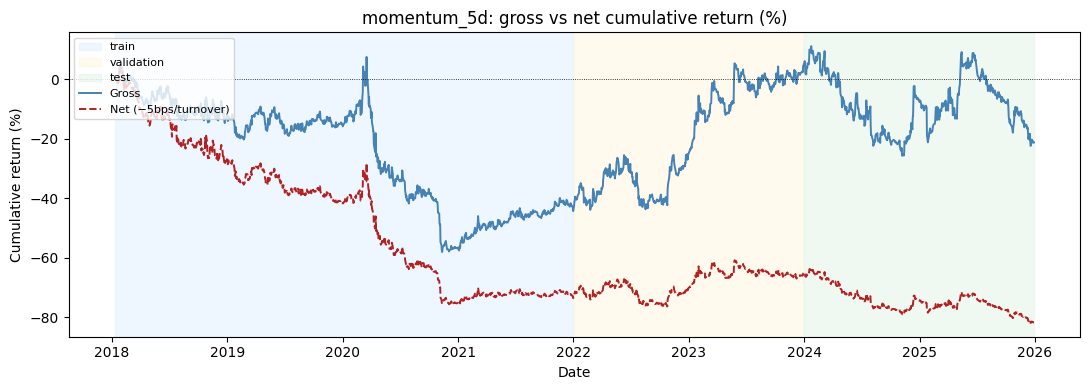

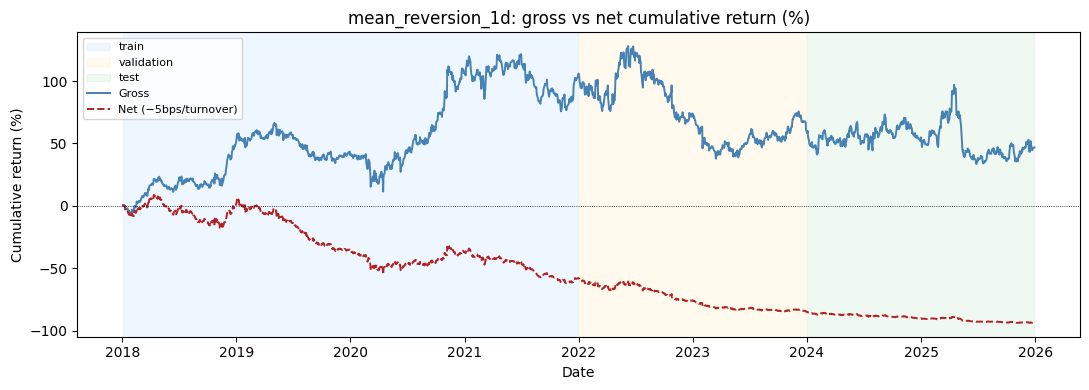

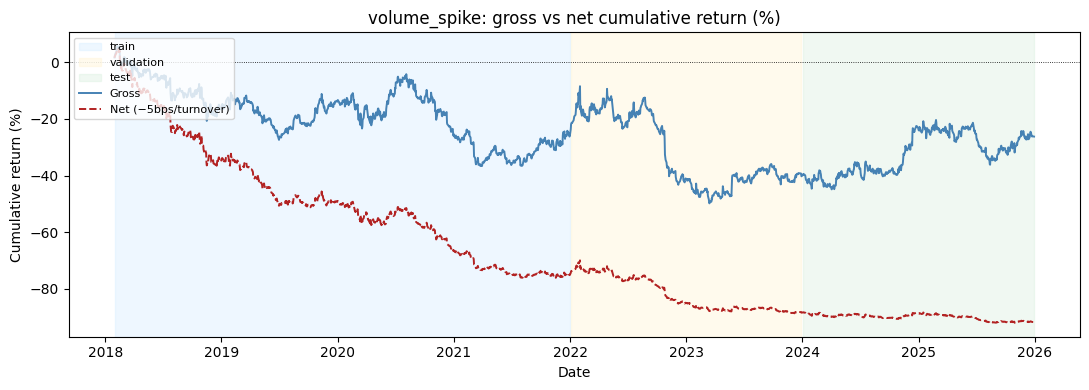

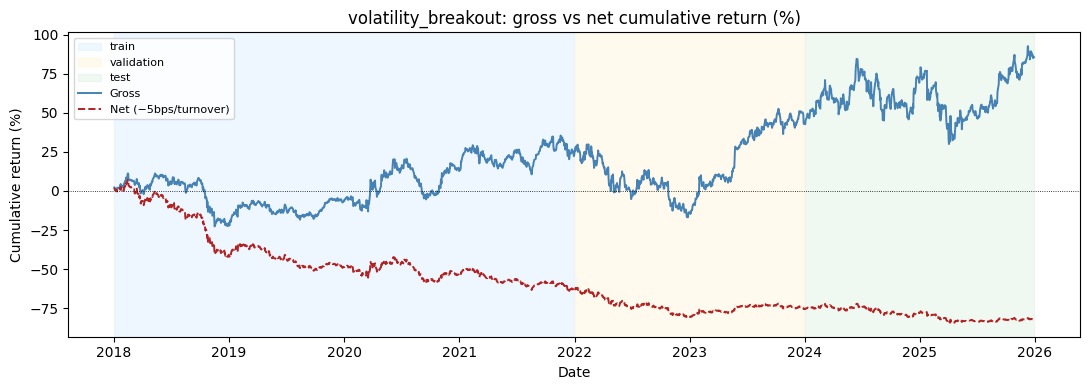

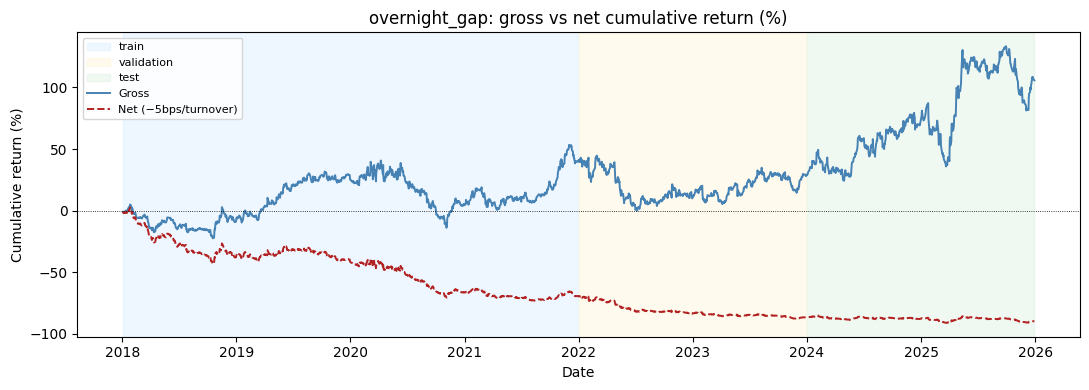

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

split_colors = {"train": "#d0eaff", "validation": "#fff3cd", "test": "#d4edda"}

for alpha in alpha_cols:
    sub = daily_returns[daily_returns["alpha"] == alpha].sort_values("date").copy()
    sub["cum_gross"] = (1 + sub["gross_return"].fillna(0)).cumprod() - 1
    sub["cum_net"]   = (1 + sub["net_return"].fillna(0)).cumprod() - 1

    fig, ax = plt.subplots(figsize=(11, 4))

    # Shade split regions
    for split, color in split_colors.items():
        mask = sub["split"] == split
        if mask.any():
            dates = sub.loc[mask, "date"]
            ax.axvspan(dates.min(), dates.max(), color=color, alpha=0.35, label=split)

    ax.plot(sub["date"], sub["cum_gross"] * 100, label="Gross", linewidth=1.4, color="steelblue")
    ax.plot(sub["date"], sub["cum_net"] * 100,   label="Net (−5bps/turnover)", linewidth=1.4,
            color="firebrick", linestyle="--")
    ax.axhline(0, color="black", linewidth=0.6, linestyle=":")

    ax.set_title(f"{alpha}: gross vs net cumulative return (%)")
    ax.set_ylabel("Cumulative return (%)")
    ax.set_xlabel("Date")
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"gross_vs_net_{alpha}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [20]:
def max_drawdown(returns):
    series = pd.Series(returns, copy=False).fillna(0.0).astype(float)
    cumulative = (1 + series).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()


def summarize_backtest(daily_returns, return_col):
    def downside_deviation(series):
        series = pd.Series(series, copy=False).dropna()
        downside = series[series < 0]
        return downside.std(ddof=0) if len(downside) else np.nan

    def win_rate(series):
        series = pd.Series(series, copy=False).dropna()
        return (series > 0).mean() if len(series) else np.nan

    def cvar_5(series):
        series = pd.Series(series, copy=False).dropna()
        if len(series) == 0:
            return np.nan
        threshold = series.quantile(0.05)
        tail = series[series <= threshold]
        return tail.mean() if len(tail) else np.nan

    summary = (
        daily_returns
        .groupby(["alpha", "split"], sort=True)
        .agg(
            avg_daily_return=(return_col, "mean"),
            median_daily_return=(return_col, "median"),
            daily_vol=(return_col, "std"),
            downside_vol=(return_col, downside_deviation),
            avg_turnover=("turnover", "mean"),
            turnover_vol=("turnover", "std"),
            win_rate=(return_col, win_rate),
            cvar_5=(return_col, cvar_5),
            days=(return_col, "count"),
        )
        .reset_index()
    )

    summary["annualized_return"] = summary["avg_daily_return"] * 252
    summary["annualized_vol"] = summary["daily_vol"] * np.sqrt(252)
    summary["sharpe"] = summary["annualized_return"] / summary["annualized_vol"].replace(0, np.nan)

    downside_annualized = summary["downside_vol"] * np.sqrt(252)
    summary["sortino"] = summary["annualized_return"] / downside_annualized.replace(0, np.nan)

    drawdown_rows = []
    for (alpha, split), group in daily_returns.groupby(["alpha", "split"], sort=True):
        group = group.sort_values("date")
        drawdown_rows.append(
            {
                "alpha": alpha,
                "split": split,
                "max_drawdown": max_drawdown(group[return_col]),
            }
        )

    drawdown_df = pd.DataFrame(drawdown_rows)
    summary = summary.merge(drawdown_df, on=["alpha", "split"], how="left")
    summary["calmar"] = summary["annualized_return"] / summary["max_drawdown"].abs().replace(0, np.nan)

    return summary


gross_backtest_by_split = summarize_backtest(daily_returns, "gross_return")
net_backtest_by_split = summarize_backtest(daily_returns, "net_return")

gross_backtest_by_split["return_type"] = "gross"
net_backtest_by_split["return_type"] = "net"

backtest_by_split = pd.concat(
    [gross_backtest_by_split, net_backtest_by_split],
    ignore_index=True,
)

backtest_by_split = backtest_by_split.sort_values(
    ["alpha", "split", "return_type"]
).reset_index(drop=True)

backtest_by_split.to_csv(DATA_DIR / "backtest_by_split.csv", index=False)
backtest_by_split.to_csv(DATA_DIR / "backtest_summary.csv", index=False)  # legacy alias

display(backtest_by_split)


,alpha,split,avg_daily_return,median_daily_return,daily_vol,downside_vol,avg_turnover,turnover_vol,win_rate,cvar_5,days,annualized_return,annualized_vol,sharpe,sortino,max_drawdown,calmar,return_type
0,mean_reversion_1d,test,-0.000053,0.000036,0.016232,0.010570,3.087000,0.647123,0.502000,-0.034155,500,-0.013437,0.257680,-0.052145,-0.080083,-0.322436,-0.041673,gross
1,mean_reversion_1d,test,-0.001597,-0.001703,0.016216,0.010676,3.087000,0.647123,0.454000,-0.035614,500,-0.402399,0.257420,-1.563202,-2.374326,-0.584840,-0.688050,net
2,mean_reversion_1d,train,0.000831,0.000580,0.015064,0.009909,3.143098,0.655903,0.524330,-0.032205,1007,0.209360,0.239131,0.875503,1.330938,-0.330821,0.632849,gross
3,mean_reversion_1d,train,-0.000741,-0.000955,0.015083,0.009963,3.143098,0.655903,0.465740,-0.033747,1007,-0.186671,0.239431,-0.779642,-1.180237,-0.651435,-0.286553,net
4,mean_reversion_1d,validation,-0.000364,-0.000371,0.015963,0.012123,3.088822,0.646216,0.493014,-0.038513,501,-0.091607,0.253410,-0.361498,-0.476032,-0.395679,-0.231519,gross
5,mean_reversion_1d,validation,-0.001908,-0.001644,0.015991,0.012105,3.088822,0.646216,0.423154,-0.040148,501,-0.480799,0.253842,-1.894083,-2.502082,-0.632156,-0.760569,net
6,momentum_5d,test,-0.000410,0.000192,0.017532,0.012582,1.423000,0.646845,0.504000,-0.040445,500,-0.103388,0.278308,-0.371488,-0.517652,-0.331525,-0.311856,gross
7,momentum_5d,test,-0.001122,-0.000521,0.017525,0.012553,1.423000,0.646845,0.474000,-0.041135,500,-0.282686,0.278204,-1.016113,-1.418559,-0.503378,-0.561579,net
8,momentum_5d,train,-0.000455,0.000340,0.015986,0.012870,1.482552,0.639630,0.513460,-0.040533,1003,-0.114567,0.253764,-0.451469,-0.560756,-0.609743,-0.187893,gross
9,momentum_5d,train,-0.001196,-0.000488,0.015991,0.012766,1.482552,0.639630,0.477567,-0.041246,1003,-0.301368,0.253842,-1.187228,-1.487067,-0.767103,-0.392865,net


In [21]:
bt_results = pd.concat(
    [long_short_backtest(df, alpha) for alpha in alpha_cols],
    ignore_index=True
)

bt_summary = (
    bt_results
    .groupby("alpha")
    .agg(
        avg_daily_return=("long_short_return", "mean"),
        daily_vol=("long_short_return", "std"),
        days=("long_short_return", "count")
    )
)

bt_summary["annualized_return"] = bt_summary["avg_daily_return"] * 252
bt_summary["annualized_vol"] = bt_summary["daily_vol"] * np.sqrt(252)
bt_summary["sharpe"] = bt_summary["annualized_return"] / bt_summary["annualized_vol"]

bt_summary = bt_summary.reset_index()  # alpha becomes a column

bt_summary.sort_values("sharpe", ascending=False)

bt_summary.to_csv(DATA_DIR / "backtest_summary.csv", index=False)

## Plot cumulative long/short returns over time

To visualize the backtest, we convert the daily long/short returns into a cumulative return curve:

\[
\text{cum\_return}(t) = \prod_{s \le t} (1 + r_{LS}(s)) - 1
\]

This compounding shows:
- whether performance is persistent or concentrated in a short window
- drawdowns (peak-to-trough declines)
- regime dependence (periods where the signal works vs. fails)

Notes:
- We fill missing daily returns with 0 before compounding, which keeps the series continuous.
  Depending on why data is missing, you may prefer to *skip* those dates instead.
- Each alpha gets its own plot so you can compare trend, volatility, and drawdown qualitatively.

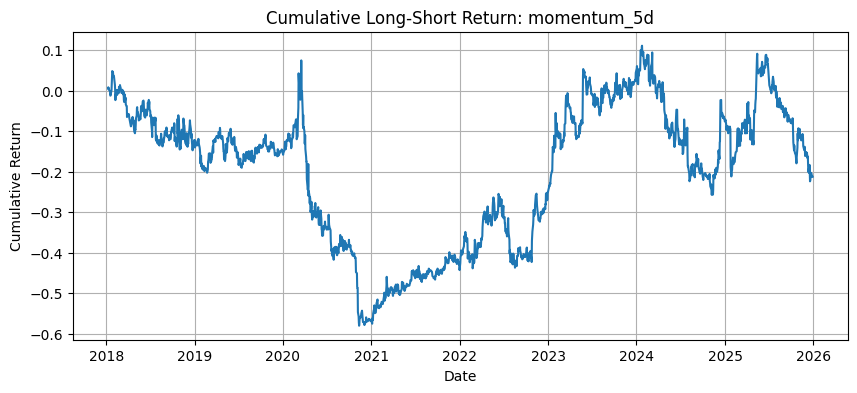

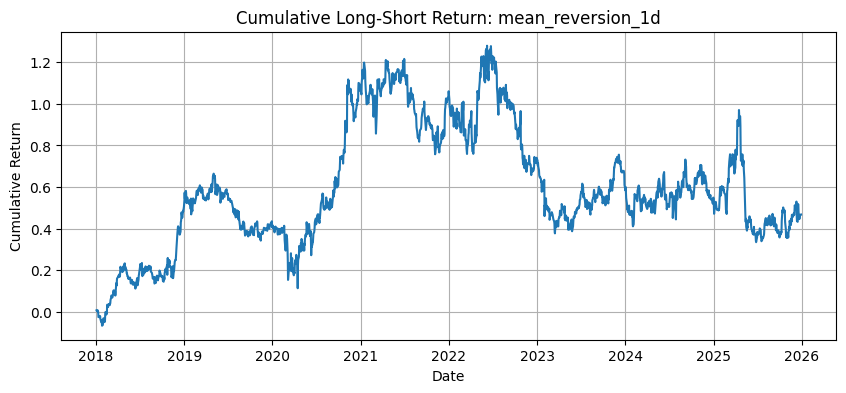

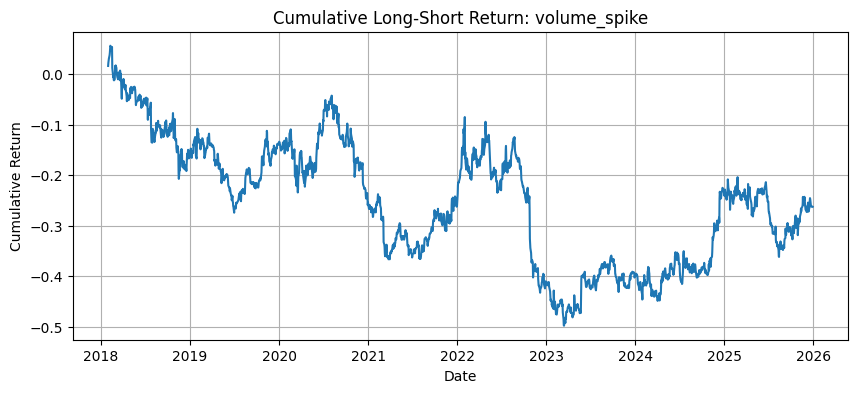

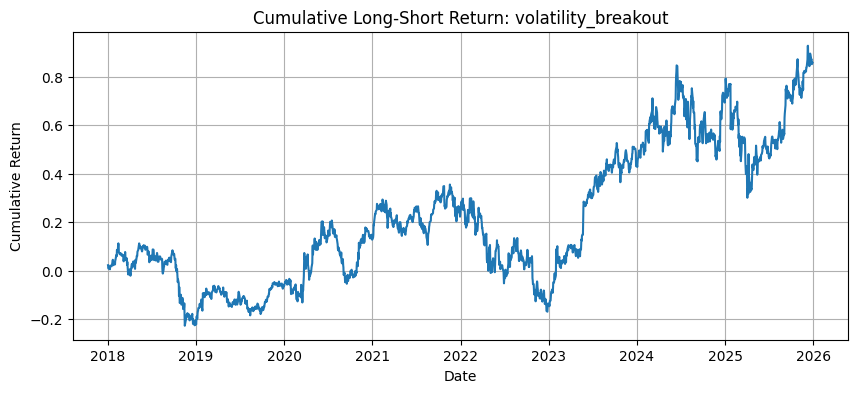

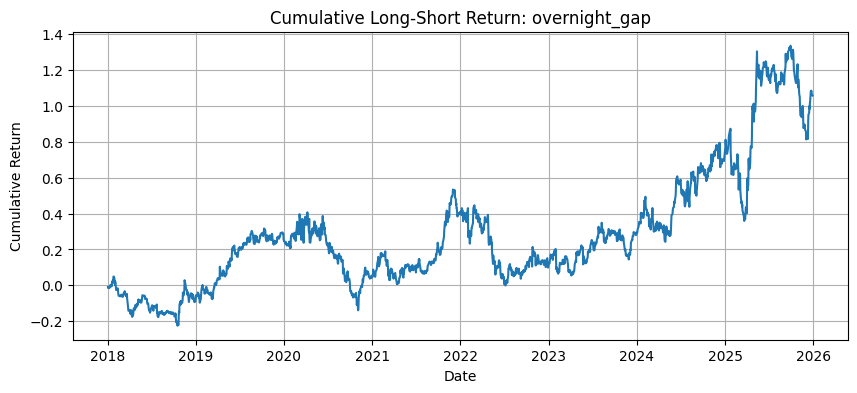

In [22]:
import matplotlib.pyplot as plt

for alpha in alpha_cols:
    temp = bt_results[bt_results["alpha"] == alpha].copy()
    temp = temp.sort_values("date")
    temp["cum_return"] = (1 + temp["long_short_return"].fillna(0)).cumprod() - 1

    plt.figure(figsize=(10, 4))
    plt.plot(temp["date"], temp["cum_return"])
    plt.title(f"Cumulative Long-Short Return: {alpha}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.savefig(FIGURE_DIR / f"cumulative_return_{alpha}.png")
    plt.show()
    plt.close()



## Observations (manual write-up)

This section summarizes what the notebook actually produced on the 20-ticker universe (2018–2025), using daily cross-sectional IC and a simple 20%/20% long-short backtest.

---

### Which alpha had the best Rank IC?

**`mean_reversion_1d`** had the highest **mean Rank IC** (~**0.0107**).

Ranking by `mean_rank_ic`:

| Rank | Alpha | mean_rank_ic |
|------|--------|----------------|
| 1 | `mean_reversion_1d` | **0.0107** |
| 2 | `overnight_gap` | 0.0078 |
| 3 | `volatility_breakout` | 0.0021 |
| 4 | `volume_spike` | -0.0041 |
| 5 | `momentum_5d` | -0.0055 |

**Interpretation:** On average, stocks with stronger 1-day mean-reversion scores tended to rank higher on next-day returns than the other signals. The effect is small in absolute terms (Rank IC near 0.01), which is typical for simple daily signals on a tiny universe.

---

### Which alpha had the best Sharpe?

**`overnight_gap`** had the highest **Sharpe** (~**0.48**), with ~**12.4%** annualized return and ~**25.9%** annualized vol in this toy backtest.

Ranking by Sharpe:

| Rank | Alpha | Sharpe | ~Ann. return |
|------|--------|--------|----------------|
| 1 | `overnight_gap` | **0.48** | ~12.4% |
| 2 | `volatility_breakout` | 0.43 | ~11.1% |
| 3 | `mean_reversion_1d` | 0.32 | ~7.9% |
| 4 | `momentum_5d` | 0.02 | ~0.5% |
| 5 | `volume_spike` | -0.09 | ~-1.8% |

**Interpretation:** The long/short rule made the most money (on paper) when sorting by overnight gap, not by mean reversion — even though mean reversion had the best Rank IC.

---

### Did IC and backtest results agree?

**Partially — not fully.** Directionally, weak signals (`volume_spike`, `momentum_5d`) look bad in both IC and Sharpe. But the “best” signal differs depending on the metric.

| Alpha | Rank IC rank | Sharpe rank | Agreement? |
|--------|--------------|-------------|------------|
| `mean_reversion_1d` | **1** | 3 | **Disagree** — best Rank IC, not best backtest |
| `overnight_gap` | 2 | **1** | **Partial** — strong in both, but Rank IC is not #1 |
| `volatility_breakout` | 3 | 2 | **Partial** — weak Rank IC, strong Sharpe |
| `momentum_5d` | 5 | 4 | **Weak** — negative IC, Sharpe ~0 |
| `volume_spike` | 4 | 5 | **Agree** — negative IC and negative Sharpe |

**Why IC and Sharpe can disagree:**

1. **IC measures correlation across all names; the backtest only trades the tails (top/bottom 20%).** A signal can have weak overall Rank IC but still work if the extreme quantiles behave differently from the middle.
2. **Pearson vs Rank IC vs quantile P&amp;L are different questions.** `overnight_gap` had the best **mean IC** (~0.0128) but not the best Rank IC.
3. **Compounding and timing.** The `overnight_gap` cumulative curve shows much of the gain concentrated in a late sample window (2024–2025), which can boost Sharpe/backtest more than average IC suggests.
4. **Small sample noise.** With ~4 names per side per day, daily long/short returns are volatile and can diverge from smooth correlation metrics.

**Bottom line:** IC is a useful *ranking* diagnostic; Sharpe is a crude *tradability* check. They should be read together, not as the same score.

---

### Which signals look suspicious?

1. **`overnight_gap` — strong backtest, but late-sample driven**  
   Cumulative return rises sharply in 2024–2025. That raises the question: is this a stable signal, or a short regime + small-universe effect?

2. **`volatility_breakout` — good Sharpe, almost no Rank IC (~0.002)**  
   Suggests the edge may come from **extreme baskets** or non-monotonic behavior, not a clean “higher alpha → higher return” relationship across the cross-section.

3. **`mean_reversion_1d` — best Rank IC, only 3rd-best Sharpe**  
   Not necessarily “wrong,” but it means the signal ranks stocks well on average while the 20%/20% long-short rule does not capture all of that edge.

4. **`momentum_5d` — negative IC, slightly positive Sharpe (~0.02)**  
   Likely **no real edge** in this setup; the tiny positive Sharpe could be noise given ~2004 days and no transaction costs.

5. **`volume_spike` — negative on both IC and Sharpe**  
   Looks like a **failed signal** in this form; I would not prioritize it without redesign (e.g., interaction with returns, dollar volume, or regime filters).

---

### What are the biggest limitations?

1. **Tiny universe (20 large-cap names)** — quantile portfolios are very small (~4 names per side); results are noisy and not representative of a broad equity book.
2. **No transaction costs, slippage, or short borrow fees** — daily long/short turnover would erode returns, especially on a small set of names.
3. **Fully in-sample (2018–2025)** — alphas were not chosen on a train set and validated on a holdout period; risk of overfitting / data mining is high.
4. **Simple execution assumptions** — close-to-close `future_return_1d` may not match when the alpha is actually tradable (especially for `overnight_gap`, which uses today’s open).
5. **No risk neutralization** — results may reflect sector/market exposures rather than pure alpha (e.g., tech-heavy winners in 2024–2025).
6. **Free yfinance data** — fine for learning, but not institutional-grade (survivorship, splits, halts, corporate actions edge cases).
7. **Hand-built features, no significance testing** — we have not tested whether IC/Sharpe differences are statistically meaningful or stable by year.

---

### What should be tested next?

*(High-level next steps; see the “Future improvements” section below for the full roadmap.)*

1. **Train / test split** — e.g., evaluate IC and Sharpe on 2018–2022 vs 2023–2025 (or walk-forward) without peeking at the test period when choosing signals.
2. **Reconcile IC vs Sharpe for the disagreeing names** — especially `volatility_breakout` and `mean_reversion_1d` (quantile returns by decile, not just top/bottom 20%).
3. **Stress-test `overnight_gap`** — rolling Sharpe, year-by-year breakdown, and check whether 2024–2025 dominates total performance.
4. **Add costs and turnover** — even a simple 5–10 bps round-trip cost model will change the ranking.
5. **Expand the universe** — move from 20 names to a few hundred (or an index constituents list) so quantile baskets are less fragile.
6. **Fix signal timing** — align each alpha with a realistic trade time (open vs close) and matching return window.
7. **Drop or redesign weak signals** — deprioritize `volume_spike` and `momentum_5d` unless new variants show holdout improvement.

**Working hypothesis after this notebook:**  
`overnight_gap` and `volatility_breakout` are the most interesting **backtest** candidates; `mean_reversion_1d` is the most interesting **Rank IC** candidate. None of these should be treated as live-trading signals until holdout testing and cost modeling are done.

## Future improvements (alphas, evaluation, and backtesting)

This notebook is a strong “minimum viable” alpha research pipeline:
download data → build a panel → compute features → evaluate via IC → sanity-check via long/short returns.
Below are the most valuable next upgrades, grouped by theme.

---

### 1) Improve the alpha features (signal quality)

**A) Make signals comparable cross-sectionally**
Raw alpha values can be dominated by outliers or differences in scale across stocks.
Common improvements:
- **Winsorize / clip** extreme values (e.g., 1st/99th percentile)
- **Cross-sectional z-score** each day (normalize within date)
- **Rank-transform** (use ranks of alpha rather than raw values)

**B) Add multi-horizon variants**
Many effects are horizon-dependent. Examples:
- momentum: 5d, 20d, 60d (and skip 1–2 day “microstructure” noise)
- mean reversion: 1d vs 2–5d (short-term reversal often differs by horizon)
- volume: volume *and* dollar volume, or volume surprise scaled by volatility

**C) Volatility scaling**
Scale signals by recent volatility so position sizing is more stable:
- `signal_scaled = signal / rolling_vol`
- or build returns-based factors like `momentum / vol`

**D) Feature interactions and regimes**
Signals can work only in certain regimes:
- trend vs. choppy markets
- high vs. low volatility
- earnings/news days
Try conditional models or regime filters.

---

### 2) Improve IC evaluation (statistical hygiene)

**A) Use Rank IC more heavily**
Rank IC is robust to outliers and non-linear relationships.
Track both Pearson and Spearman, but prefer Rank IC for “factor-like” signals.

**B) Add significance diagnostics**
Beyond mean/stdev:
- **t-stat** of IC (\( \bar{IC} / (s_{IC}/\sqrt{T}) \))
- confidence intervals via bootstrap
- stability by year / regime split (2018–2020 vs 2021–2025, etc.)

**C) Neutralize common risks**
Many “alphas” are actually exposures to:
- market beta
- sector effects
- size (market cap)
Consider:
- sector-neutral ranking
- beta-neutral / residualized returns (regress out market)

---

### 3) Improve the long/short backtest (realism and robustness)

**A) Portfolio construction**
Right now, you average returns of long and short baskets equally.
Next steps:
- **Weighting schemes**: equal-weight vs. rank-weight vs. z-score-weight
- **Volatility targeting**: scale exposure so portfolio risk is stable over time
- **Dollar neutrality**: ensure long and short legs have equal gross exposure

**B) Costs and frictions (most important for realism)**
Even simple estimates help:
- transaction costs per trade (bps)
- slippage proportional to volatility / volume
- turnover tracking (how much you trade each day)
- borrow cost / short constraints (hard-to-borrow names)

**C) Timing alignment**
Be explicit about when the alpha is known vs. when you trade:
- if alpha uses close(t), you can only trade at close(t) or next open
- if alpha uses open(t), you can trade after open(t)
Match the target return window accordingly (open-to-close, close-to-close, etc.)

**D) Quantile size and universe size**
With 20 tickers and 20% tails, you have ~4 names per side.
This is noisy. Improvements:
- expand the universe (more tickers)
- test multiple quantiles (10%, 20%, 30%)
- compute “spread” between top and bottom deciles when universe is large enough

**E) Better performance reporting**
Add:
- max drawdown
- rolling Sharpe / rolling volatility
- hit rate (% positive days)
- worst/best day, tail risk (skew/kurtosis)
- per-year breakdown to see regime dependence

---

### 4) Data engineering and reproducibility

**A) Cache data locally**
Save cleaned panel data (prefer Parquet) so reruns don’t re-download.

**B) Validate inputs**
Basic checks catch subtle bugs:
- missing dates per ticker
- duplicated rows
- non-positive prices/volumes
- rolling window warm-up handling

**C) Separate “research” and “library” code**
As the project grows:
- move reusable logic into `alphaforge/` (feature builders, IC, backtester)
- keep notebooks thin and narrative-driven

---

### 5) Next research milestones

- Add more alphas (quality, value, volatility, liquidity, trend, reversal variants).
- Combine alphas into a composite (simple averaging, regression, or ML).
- Use walk-forward evaluation / train-test splits to reduce overfitting risk.
- Expand universe and add sector constraints and realistic trading assumptions.